In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.simplefilter("ignore")

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# converting totalchage into numeric 
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [6]:
df['TotalCharges'].isnull().sum()

11

In [7]:
# deleting null vAlues
df.dropna(how='any', inplace=True)

In [8]:
df.drop(['customerID'], axis='columns', inplace=True)
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [9]:
df = pd.get_dummies(df,drop_first=True, dtype='int')
df.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int32  
 5   Partner_Yes                            7032 non-null   int32  
 6   Dependents_Yes                         7032 non-null   int32  
 7   PhoneService_Yes                       7032 non-null   int32  
 8   MultipleLines_No phone service         7032 non-null   int32  
 9   MultipleLines_Yes                      7032 non-null   int32  
 10  InternetService_Fiber optic            7032 non-null   int32  
 11  InternetS

In [11]:
# considering churn y variable and x variable in other
x = df.drop(['Churn_Yes'], axis=1)
y = df['Churn_Yes']

In [12]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,1,1,1,1,0,1,...,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,1,1,1,0,1,...,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,1,1,0,1,0,...,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,1


In [13]:
y


0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn_Yes, Length: 7032, dtype: int32

In [14]:
# split the data inot training and testing
x_train,x_test ,y_train,y_test = train_test_split(x,y, test_size=0.25,random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [16]:
# build the base model 

model_org = LogisticRegression()
model_org.fit(x_train_sc,y_train)

y_pred_org = model_org.predict(x_test_sc)

accuracy_org = accuracy_score(y_pred_org,y_test)*100
print('Accuracy of the base model is: ',(accuracy_org))

Accuracy of the base model is:  79.01023890784982


## Apply PCA

In [17]:
pca = PCA(n_components=10)
x_train_pca = pca.fit_transform(x_train_sc)
x_test_pca = pca.transform(x_test_sc)

In [18]:
explained_varience = pca.explained_variance_ratio_
print(explained_varience)

[0.33205354 0.11999793 0.09045657 0.04707135 0.04165786 0.0411608
 0.03795099 0.03349116 0.03094919 0.02939063]


In [19]:
# trai n ing the logstic regressiom 

model_pca = LogisticRegression()
model_pca.fit(x_train_pca,y_train)

y_pred_pca = model_pca.predict(x_test_pca)

accuracy_pca = accuracy_score(y_pred_pca,y_test)*100
print('Accuracy of the base model is: ',(accuracy_org))

Accuracy of the base model is:  79.01023890784982


## Applying the LDA

In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
x_train_lda = lda.fit_transform(x_train_sc,y_train)
x_test_lda = lda.transform(x_test_sc)

In [21]:
explained_varience_lda = lda.explained_variance_ratio_
print(explained_varience_lda)

[1.]


In [22]:
# trai n ing the logstic regressiom 

model_lda = LogisticRegression()
model_lda.fit(x_train_lda,y_train)

y_pred_lda = model_lda.predict(x_test_lda)

accuracy_lda = accuracy_score(y_pred_lda,y_test)*100
print('Accuracy of the lda model is: ',(accuracy_lda))

Accuracy of the lda model is:  79.18088737201366


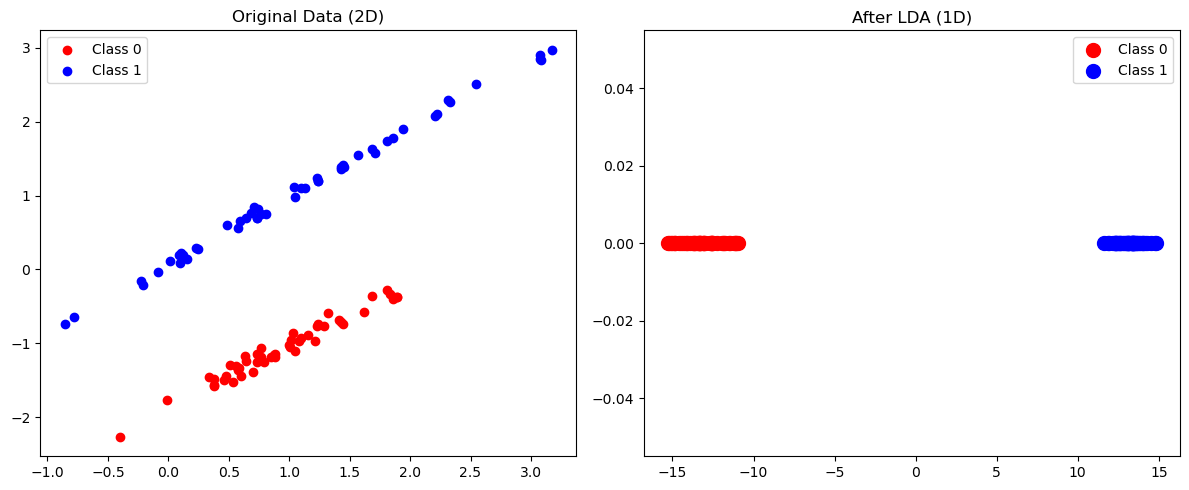

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.datasets import make_classification

# Generate sample data
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0, n_informative=2,
                         n_clusters_per_class=1, n_classes=2, random_state=42)

# Apply LDA
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

# Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], c='red', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class 1')
plt.title('Original Data (2D)')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_lda[y==0], np.zeros_like(X_lda[y==0]), c='red', label='Class 0', s=100)
plt.scatter(X_lda[y==1], np.zeros_like(X_lda[y==1]), c='blue', label='Class 1', s=100)
plt.title('After LDA (1D)')
plt.legend()

plt.tight_layout()
plt.show()